## Business Objective
TalentPuls wants to replace the lookup-table salary estimation with a regression model that predicts **salary_avg** more accurately. The company specifically wants to capture the effects of:

- Seniority
- Country
- Remote work
- Skills
- Experience

In [14]:
# Standard data tools
import numpy as np                   
import pandas as pd                  

# Visualisation tools 
import matplotlib.pyplot as plt      
import matplotlib.cm as cm
import seaborn as sns  
import missingno as msno # Missing data - Data visualization
import re

# Settings 
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [15]:
# Load Data

job_df = pd.read_csv("jobs_dataset.csv")

In [16]:
# Convert all column names to lowercase
job_df.columns = job_df.columns.str.lower()

print("✅ All table column names converted to lowercase.")

✅ All table column names converted to lowercase.


### Data Investigation & Cleaning

### Data Structure Validation

In [17]:
# Index to assess the position of values inside a list

print(f"Dataset shape: {job_df.shape[0]:,} rows x {job_df.shape[1]:,} columns")

Dataset shape: 4,653 rows x 17 columns


In [18]:
# List All Column Titles

job_df.columns

Index(['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary'],
      dtype='object')

In [19]:
# Standardize column names
job_df.columns = (
    job_df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
)

In [20]:
job_df.columns

Index(['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary'],
      dtype='object')

In [21]:
# View All the Data Types 

job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   object 
 2   company              4652 non-null   object 
 3   location             4653 non-null   object 
 4   salary_min           2299 non-null   float64
 5   salary_max           2295 non-null   float64
 6   description          4653 non-null   object 
 7   country              4653 non-null   object 
 8   search_keyword       4653 non-null   object 
 9   experience_required  487 non-null    float64
 10  degree_required      4653 non-null   object 
 11  skills               4653 non-null   object 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   object 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2299 non-null   f

### Data Quality Validation

In [34]:
# Investigate missing values

missing = (
    job_df
    .isnull()
    .sum()
    .to_frame("Missing")
)

missing["% Missing"] = (
    missing["Missing"] /
    len(job_df)
)*100

missing = missing.sort_values(
    "% Missing",
    ascending=False
)

# Displaying values > 0.0
missing[missing["% Missing"] > 0.0]

,Missing,% Missing
experience_required,4166,89.533634
salary_max,2358,50.676983
salary_avg,2354,50.591017
salary_min,2354,50.591017
company,1,0.021492


***Comment:***


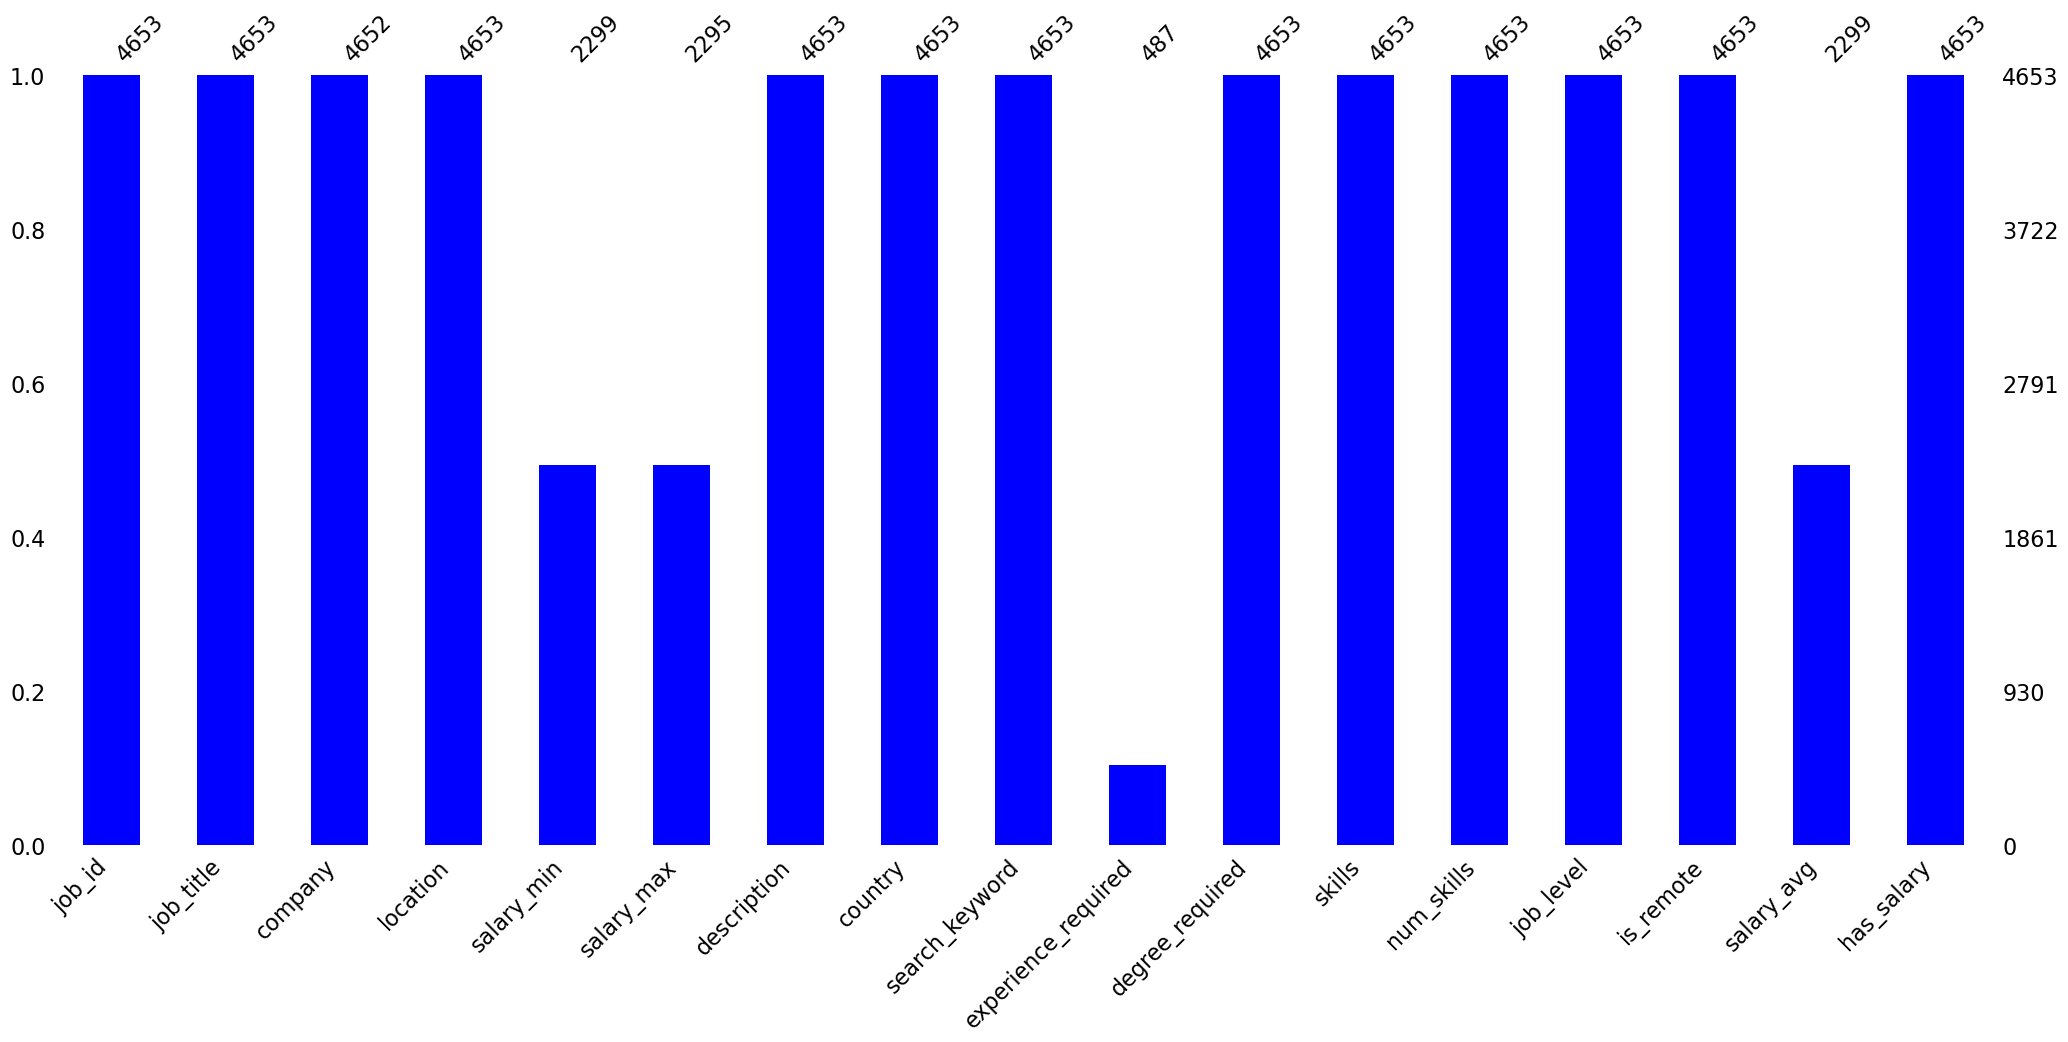

In [35]:
# Visualize as a Bar plot

msno.bar(job_df, color="blue")
plt.show()

In [36]:
# Check for unique values
job_df.nunique().sort_values()

has_salary                2
is_remote                 2
job_level                 4
degree_required           4
country                   5
search_keyword            5
num_skills                6
experience_required      42
skills                   51
location                833
job_title              1513
salary_min             1824
salary_max             1831
company                1851
salary_avg             1900
description            3361
job_id                 4653
dtype: int64

In [77]:
# Correct Spellings
spelling_corrections = {
    r"\bdata scienctist\b": "data scientist",
    r"\bdata scientest\b": "data scientist",
    r"\bdata enginner\b": "data engineer",
    r"\bdata engneer\b": "data engineer",
    r"\bdata analyist\b": "data analyst",
    r"\bdata analist\b": "data analyst",
    r"\bmachine learing\b": "machine learning",
    r"\bmachine learnig\b": "machine learning",
    r"\bbusiness analyist\b": "business analyst",
    r"\bbuisness analyst\b": "business analyst",
}


# Standard phrases that should retain specific formatting
phrase_corrections = {
    r"\be commerce\b": "E-Commerce",
    r"\be-commerce\b": "E-Commerce",
    r"\bmachine learning operations\b": "Machine Learning Operations",
    r"\bdata science and mlops\b": "Data Science & MLOps",
    r"\bdata science & mlops\b": "Data Science & MLOps",
    r"\bai and ml\b": "AI & ML",
    r"\bai & ml\b": "AI & ML",
    r"\bgen ai\b": "GenAI",
    r"\bgenerative ai\b": "Generative AI",
    r"\bbusiness intelligence\b": "Business Intelligence",
}


# Acronyms requiring uppercase or specialist casing
acronym_corrections = {
    r"\bAi\b": "AI",
    r"\bMl\b": "ML",
    r"\bBia\b": "BIA",
    r"\bGps\b": "GPS",
    r"\bAws\b": "AWS",
    r"\bGcp\b": "GCP",
    r"\bSql\b": "SQL",
    r"\bNlp\b": "NLP",
    r"\bLlm\b": "LLM",
    r"\bRag\b": "RAG",
    r"\bBi\b": "BI",
    r"\bEtl\b": "ETL",
    r"\bApi\b": "API",
    r"\bSap\b": "SAP",
    r"\bCrm\b": "CRM",
    r"\bErp\b": "ERP",
    r"\bCdp\b": "CDP",
    r"\bPmo\b": "PMO",
    r"\bSme\b": "SME",
    r"\bMLOps\b": "MLOps",
    r"\bMlops\b": "MLOps",
    r"\bDevops\b": "DevOps",
    r"\bPyspark\b": "PySpark",
    r"\bGenai\b": "GenAI",
     r"\bssis\b": "SSIS",
    r"\bssrs\b": "SSRS",
}


# Roman numerals commonly used for job grades
roman_numeral_corrections = {
    r"\bI\b": "I",
    r"\bIi\b": "II",
    r"\bIii\b": "III",
    r"\bIv\b": "IV",
    r"\bV\b": "V",
    r"\bVi\b": "VI",
}

In [84]:
# Conserve clean job titles while preserving their original meaning.

def clean_job_title(title):
        
    if pd.isna(title):
        return pd.NA

    title = str(title).lower().strip()

# 1. Remove recruitment/reference identifiers

    title = re.sub(
        r"^\s*\(\s*\d{4,}\s*\)\s*",
        "",
        title
    )

    title = re.sub(
        r"\[\s*(?:t\d+|req(?:uisition)?|job|ref(?:erence)?|vacancy|id)"
        r"[\s:#_\-]*\d+(?:[\s:#_\-]+\d+)*\s*\]",
        " ",
        title,
        flags=re.IGNORECASE
    )

    title = re.sub(
        r"\s+\b\d{5,}\b\s*$",
        "",
        title
    )

    title = re.sub(
        r"\b(?:req(?:uisition)?|job|reference|ref|vacancy)"
        r"\s*(?:id|code|number|no)?\s*[:#\-]?\s*[a-z]*\d+\b",
        " ",
        title,
        flags=re.IGNORECASE
    )

    # Remove standalone long reference numbers at the end
    title = re.sub(
        r"\s+\b\d{5,}\b\s*$",
        " ",
        title,
    )

# 2. Correct obvious spelling mistakes

    for pattern, replacement in spelling_corrections.items():
        title = re.sub(
            pattern,
            replacement,
            title,
            flags=re.IGNORECASE,
        )

# 3. Normalize punctuation and spacing
    # Duplicated punctuation
    title = re.sub(r"\.{2,}", ".", title)
    title = re.sub(r",{2,}", ",", title)
    title = re.sub(r";{2,}", ";", title)
    title = re.sub(r":{2,}", ":", title)
    title = re.sub(r"/{2,}", "/", title)
    title = re.sub(r"&{2,}", "&", title)
    title = re.sub(r"[-–—]{2,}", "-", title)

    # Remove unnecessary dot after seniority terms
    title = re.sub(
        r"\b(senior|junior|lead|principal|staff|associate|manager|director)"
        r"\.\s+",
        r"\1 ",
        title
    )


    # Normalize spaces around punctuation
    title = re.sub(r"\s+([,.;:)\]])", r"\1", title)
    title = re.sub(r"([(\[])\s+", r"\1", title)

    title = re.sub(r"\s*/\s*", " / ", title)
    title = re.sub(r"\s*&\s*", " & ", title)
    title = re.sub(r"\s*[-–—]\s*", " - ", title)

    # Collapse repeated whitespace
    title = re.sub(r"\s+", " ", title).strip()

# 4. Apply general title case

    title = title.title()
    title = re.sub(r"'S\b", "'s", title)
    title = re.sub(r"\.Net\b", ".NET", title)
    title = re.sub(r"\bC\+\+\b", "C++", title)
    title = re.sub(r"\bC#\b", "C#", title)

# 5. Restore standard technical phrases

    for pattern, replacement in phrase_corrections.items():
        title = re.sub(
            pattern,
            replacement,
            title,
            flags=re.IGNORECASE
        )

# 6. Restore acronyms and specialist casing

    for pattern, replacement in acronym_corrections.items():
        title = re.sub(
            pattern, 
            replacement, 
            title,
            flags=re.IGNORECASE
        )

# 7. Restore Roman numeral job grades

    for pattern, replacement in roman_numeral_corrections.items():
        title = re.sub(pattern, replacement, title)

    # Final whitespace cleanup
    title = re.sub(r"\s+", " ", title).strip()
    
    return title

In [85]:
if "job_title_raw" not in job_df.columns:
    job_df["job_title_raw"] = job_df["job_title"].copy()


job_df["job_title_clean"] = (
    job_df["job_title_raw"]
    .apply(clean_job_title)
)

In [86]:
pd.set_option("display.max_colwidth", None)

In [87]:
title_audit = (
    job_df.loc[
        job_df["job_title_raw"] != job_df["job_title_clean"],
        ["job_title_raw", "job_title_clean"]
    ]
    .drop_duplicates()
    .sort_values("job_title_raw")
)


In [88]:
title_audit

,job_title_raw,job_title_clean
2343,(197276) sole data engineer,Sole Data Engineer
873,.net developer (ssis / sseniors / sql development),.NET Developer (SSIS / Sseniors / SQL Development)
3522,"2026 fall student opportunities rbc borealis machine learning software engineer, 4 8 months","2026 Fall Student Opportunities Rbc Borealis Machine Learning Software Engineer, 4 8 Months"
4406,2027 graduate program,2027 Graduate Program
3550,acceleration kernel developer intern,Acceleration Kernel Developer Intern
...,...,...
747,vp business analyst sme,Vp Business Analyst SME
739,workday business analyst,Workday Business Analyst
4458,workforce planning project manager (mgr project management 3) 28162,Workforce Planning Project Manager (Mgr Project Management 3)
2229,workplace data analyst m&g plc.,Workplace Data Analyst M & G Plc.


In [91]:
# Job Title Inspection
mask = job_df["job_title_raw"].str.contains(
    "sseniors",
    case=False,
    na=False
)

job_df.loc[
    mask,
    ["job_title_raw", "description"]
]["description"].iloc[0]

'About Company, Droisys is an innovation technology company focused on helping companies accelerate their digital initiatives from strategy and planning through execution. We leverage deep technical expertise, Agile methodologies, and data-driven intelligence to modernize systems of engagement and simplify human/tech interaction. Amazing things happen when we work in environments where everyone feels a true sense of belonging and when candidates have the requisite skills and opportunities to suc…'

In [92]:
description_text = job_df.loc[mask, "description"].iloc[0].lower()

keywords = [
    "ssrs",
    "reporting services",
    "sql server reporting services",
    "report development",
    "reports"
]

for keyword in keywords:
    print(keyword, keyword in description_text)

ssrs False
reporting services False
sql server reporting services False
report development False
reports False


In [95]:
# Flag record for manual review
job_df["job_title_review_flag"] = False

mask = job_df["job_title_raw"].str.contains(
    r"\bsseniors\b",
    case=False,
    na=False,
    regex=True
)

job_df.loc[mask, "job_title_review_flag"] = True

# Create review note 
job_df["job_title_review_note"] = pd.NA

job_df.loc[
    mask,
    "job_title_review_note"
] = "Ambiguous term 'sseniors'; source description does not confirm intended wording."

print("⚠️ Ambiguous term 'sseniors'; source description does not confirm intended wording.")

⚠️ Ambiguous term 'sseniors'; source description does not confirm intended wording.


In [ ]:
# Job Title Inspection
mask = job_df["job_title_raw"].str.contains(
    "sseniors",
    case=False,
    na=False
)

job_df.loc[
    mask,
    ["job_title_raw", "description"]
]["description"].iloc[0]

In [96]:
# Create a review table for Flagging
review_titles = job_df.loc[
    job_df["job_title_review_flag"],
    [
        "job_title_raw",
        "job_title_clean",
        "job_title_review_note"
    ]
]

In [97]:
review_titles

,job_title_raw,job_title_clean,job_title_review_note
873,.net developer (ssis / sseniors / sql development),.NET Developer (SSIS / Sseniors / SQL Development),Ambiguous term 'sseniors'; source description does not confirm intended wording.


#### Data Quality Assessment

In [99]:
# Review ALL Job Titles

# Each rule contains:
# - regex pattern
# - review reason
# - review priority

TITLE_REVIEW_RULES = {
    "ambiguous_or_unresolved_term": {
        "pattern": (
            r"\b("
            r"sseniors|"
            r"riskpo|"
            r"penndna|"
            r"sqletlpyspark|"
            r"agenticai|"
            r"aiml|"
            r"llmrag"
            r")\b"
        ),
        "reason": "Contains an ambiguous, concatenated, or unresolved term.",
        "priority": "High",
    },

    "recruitment_campaign": {
        "pattern": (
            r"\b("
            r"graduate program(?:me)?|"
            r"student opportunities|"
            r"training program(?:me)?|"
            r"training pathway|"
            r"certification program(?:me)?|"
            r"online course|"
            r"career pathway|"
            r"campus technical learning"
            r")\b"
        ),
        "reason": (
            "Appears to describe a recruitment, education, or training "
            "campaign rather than a specific vacancy."
        ),
        "priority": "Medium",
    },

    "hiring_or_application_message": {
        "pattern": (
            r"\b("
            r"is hiring|"
            r"multiple roles|"
            r"opportunity for|"
            r"immediate joiner|"
            r"immediate joiners|"
            r"immediate joinees|"
            r"only immediate joiner accepted|"
            r"face to face interview|"
            r"short np|"
            r"notice period|"
            r"mandatory"
            r")\b"
        ),
        "reason": (
            "Contains recruitment instructions or advertising language "
            "that may not belong to the occupational title."
        ),
        "priority": "High",
    },

    "location_or_work_condition_embedded": {
        "pattern": (
            r"(@\s*[A-Za-z]+)|"
            r"\b("
            r"pan india|"
            r"any ust location|"
            r"onsite|"
            r"full time|"
            r"contract|"
            r"remote immediate|"
            r"thane,\s*mumbai|"
            r"sholinganallur"
            r")\b"
        ),
        "reason": (
            "Contains location, employment condition, or work-arrangement "
            "information embedded in the title."
        ),
        "priority": "Medium",
    },

    "experience_requirement_embedded": {
        "pattern": (
            r"\b\d+\s*(?:-|–|to)?\s*\d*\s*"
            r"(?:years?|yrs?|yoe)\b"
        ),
        "reason": "Contains years-of-experience information embedded in the title.",
        "priority": "Medium",
    },

    "salary_or_compensation_embedded": {
        "pattern": (
            r"\b\d+\s*[-–]\s*\d+\s*(?:l|lpa|lakhs?|k)\b|"
            r"[$£€]\s*\d+"
        ),
        "reason": "Contains apparent salary or compensation information.",
        "priority": "High",
    },

    "numeric_reference_code": {
        "pattern": (
            r"^\s*[\[(]?\d{4,}[\])]?|"
            r"\b(?:job|req|ref|vacancy|ihc)\s*[-:#]?\s*\d+\b|"
            r"\b[A-Za-z]{2,}\d{3,}\b"
        ),
        "reason": "Contains a possible recruitment, vacancy, or internal reference code.",
        "priority": "Medium",
    },

    "unusual_separator": {
        "pattern": (
            r"\|\||"
            r"\|[^|]+\||"
            r"（|"
            r"）"
        ),
        "reason": "Contains unusual or repeated separators requiring review.",
        "priority": "Medium",
    },

    "unbalanced_brackets": {
        # This rule is handled separately below because regex alone
        # cannot reliably count paired brackets.
        "pattern": None,
        "reason": "Contains unmatched or unbalanced brackets/parentheses.",
        "priority": "High",
    },

    "generic_non_specific_title": {
        "pattern": (
            r"^(Analyst|Developer|Consultant|Architect|"
            r"Manager|Assistant Manager|Senior Associate|"
            r"Associate|Lead Engineer|Product Manager)$"
        ),
        "reason": (
            "Title is highly generic and may not provide enough occupational "
            "information for salary modelling."
        ),
        "priority": "Low",
    },

    "possible_role_campaign_or_company_description": {
        "pattern": (
            r"^(Leading .* Company|"
            r"AI / ML Inference .* Giant|"
            r"TCS Interview|"
            r"TCS Is Hiring)"
        ),
        "reason": (
            "Title appears to contain a company description or advertisement "
            "rather than only the advertised role."
        ),
        "priority": "High",
    },

    "possible_malformed_technology": {
        "pattern": (
            r"\b("
            r"4Hana|"
            r"S / 4Hana|"
            r"S / 4 Hana|"
            r"Dbt|"
            r"Sdk|"
            r"Finops|"
            r"Iics|"
            r"Siem|"
            r"Ecommerce|"
            r"Servicenow|"
            r"Opentext|"
            r"Erpnext"
            r")\b"
        ),
        "reason": (
            "Contains a technology term whose spelling or capitalization "
            "may require controlled standardization."
        ),
        "priority": "Low",
    },

    "very_long_title": {
        # Handled separately using string length.
        "pattern": None,
        "reason": (
            "Title is unusually long and may contain job-description, "
            "location, salary, or application details."
        ),
        "priority": "High",
    },
}

In [100]:
# Build a Function that evaluates one clean job title
# and return all appplicable reveiw issues.
# The function does not alter the title

def review_job_title(title, long_title_threshold=120):
    
    if pd.isna(title) or not str(title).strip():
        return [{
            "rule": "missing_or_blank_title",
            "reason": "Job title is missing or blank.",
            "priority": "High",
        }]

    title = str(title).strip()
    issues = []

    # Apply regex-based rules
    for rule_name, rule in TITLE_REVIEW_RULES.items():

        if rule["pattern"] is None:
            continue

        if re.search(
            rule["pattern"],
            title,
            flags=re.IGNORECASE
        ):
            issues.append({
                "rule": rule_name,
                "reason": rule["reason"],
                "priority": rule["priority"],
            })

    # Check title length
    if len(title) > long_title_threshold:
        rule = TITLE_REVIEW_RULES["very_long_title"]

        issues.append({
            "rule": "very_long_title",
            "reason": rule["reason"],
            "priority": rule["priority"],
        })

    # Check balanced parentheses and brackets
    bracket_pairs = {
        "(": ")",
        "[": "]",
    }

    for opening, closing in bracket_pairs.items():
        if title.count(opening) != title.count(closing):
            rule = TITLE_REVIEW_RULES["unbalanced_brackets"]

            issues.append({
                "rule": "unbalanced_brackets",
                "reason": rule["reason"],
                "priority": rule["priority"],
            })
            break

    # Detect abnormal repeated punctuation
    if re.search(r"[!?.,;:/|]{3,}", title):
        issues.append({
            "rule": "repeated_punctuation",
            "reason": "Contains three or more consecutive punctuation marks.",
            "priority": "Medium",
        })

    return issues

In [101]:
# Loop the function

review_records = []

for index, row in job_df.iterrows():

    clean_title = row.get("job_title_clean", pd.NA)
    issues = review_job_title(clean_title)

    for issue in issues:
        review_records.append({
            "row_index": index,
            "job_id": row.get("job_id", pd.NA),
            "job_title_raw": row.get("job_title_raw", pd.NA),
            "job_title_clean": clean_title,
            "company": row.get("company", pd.NA),
            "country": row.get("country", pd.NA),
            "review_rule": issue["rule"],
            "review_reason": issue["reason"],
            "review_priority": issue["priority"],
        })

job_title_review_long = pd.DataFrame(review_records)

In [105]:
# Create consolidated review row per job 
if not job_title_review_long.empty:

    priority_order = {
        "High": 3,
        "Medium": 2,
        "Low": 1
    }

    job_title_review_long["priority_score"] = (
        job_title_review_long["review_priority"]
        .map(priority_order)
    )

    job_title_review_table = (
        job_title_review_long
        .groupby(
            [
                "row_index",
                "job_id",
                "job_title_raw",
                "job_title_clean",
                "company",
                "country"
            ],
            dropna=False,
            as_index=False
        )
        .agg(
            review_rules=(
                "review_rule",
                lambda values: " | ".join(
                    sorted(set(values))
                )
            ),
            review_reasons=(
                "review_reason",
                lambda values: " | ".join(
                    sorted(set(values))
                )
            ),
            priority_score=("priority_score", "max"),
            issue_count=("review_rule", "nunique")
        )
    )

    reverse_priority = {
        3: "High",
        2: "Medium",
        1: "Low"
    }

    job_title_review_table["review_priority"] = (
        job_title_review_table["priority_score"]
        .map(reverse_priority)
    )

    job_title_review_table["review_status"] = "Pending"

    job_title_review_table["review_decision"] = pd.NA
    job_title_review_table["reviewer_note"] = pd.NA

    job_title_review_table = (
        job_title_review_table
        .drop(columns="priority_score")
        .sort_values(
            ["review_priority", "issue_count"],
            ascending=[True, False],
            key=lambda column: (
                column.map(
                    {"High": 1, "Medium": 2, "Low": 3}
                )
                if column.name == "review_priority"
                else column
            )
        )
        .reset_index(drop=True)
    )

else:
    job_title_review_table = pd.DataFrame()

In [103]:
# Add Flag
job_df["job_title_review_flag"] = False
job_df["job_title_review_note"] = pd.NA
job_df["job_title_review_priority"] = pd.NA

if not job_title_review_table.empty:

    flagged_indices = job_title_review_table["row_index"]

    job_df.loc[
        flagged_indices,
        "job_title_review_flag"
    ] = True

    reason_map = (
        job_title_review_table
        .set_index("row_index")["review_reasons"]
    )

    priority_map = (
        job_title_review_table
        .set_index("row_index")["review_priority"]
    )

    job_df.loc[
        flagged_indices,
        "job_title_review_note"
    ] = flagged_indices.map(reason_map)

    job_df.loc[
        flagged_indices,
        "job_title_review_priority"
    ] = flagged_indices.map(priority_map)

In [104]:
# View review table
pd.set_option("display.max_colwidth", None)

job_title_review_table[
    [
        "row_index",
        "job_id",
        "job_title_raw",
        "job_title_clean",
        "review_priority",
        "issue_count",
        "review_rules",
        "review_reasons",
        "review_status"
    ]
].head(100)

,row_index,job_id,job_title_raw,job_title_clean,review_priority,issue_count,review_rules,review_reasons,review_status
0,713,5704488358,ai/ml inference sdk lead for a wireless tech giant @hyderabad/strong work experience with c++ is mandatory/65 80l/experience with ai hardware accelerators,AI / ML Inference Sdk Lead For A Wireless Tech Giant @Hyderabad / Strong Work Experience With C++ Is Mandatory / 65 80L / Experience With AI Hardware Accelerators,High,5,hiring_or_application_message | location_or_work_condition_embedded | possible_malformed_technology | possible_role_campaign_or_company_description | very_long_title,"Contains a technology term whose spelling or capitalization may require controlled standardization. | Contains location, employment condition, or work-arrangement information embedded in the title. | Contains recruitment instructions or advertising language that may not belong to the occupational title. | Title appears to contain a company description or advertisement rather than only the advertised role. | Title is unusually long and may contain job-description, location, salary, or application details.",Pending
1,297,5697210442,data analyst – sap / sap mdg | 5 yoe | any ust location | immediate joiner,Data Analyst - SAP / SAP Mdg | 5 Yoe | Any Ust Location | Immediate Joiner,High,4,experience_requirement_embedded | hiring_or_application_message | location_or_work_condition_embedded | unusual_separator,"Contains location, employment condition, or work-arrangement information embedded in the title. | Contains recruitment instructions or advertising language that may not belong to the occupational title. | Contains unusual or repeated separators requiring review. | Contains years-of-experience information embedded in the title.",Pending
2,795,5643596657,"functional test lead（only short np less than 60 days accepted, kindly pay attention to this to save your efforts, thank you for understanding)","Functional Test Lead（Only Short Np Less Than 60 Days Accepted, Kindly Pay Attention To This To Save Your Efforts, Thank You For Understanding)",High,4,hiring_or_application_message | unbalanced_brackets | unusual_separator | very_long_title,"Contains recruitment instructions or advertising language that may not belong to the occupational title. | Contains unmatched or unbalanced brackets/parentheses. | Contains unusual or repeated separators requiring review. | Title is unusually long and may contain job-description, location, salary, or application details.",Pending
3,797,5711045977,"middleware engineer – oracle business activity monitoring (bam) || thane, mumbai || contract || face to face interview","Middleware Engineer - Oracle Business Activity Monitoring (Bam) || Thane, Mumbai || Contract || Face To Face Interview",High,3,hiring_or_application_message | location_or_work_condition_embedded | unusual_separator,"Contains location, employment condition, or work-arrangement information embedded in the title. | Contains recruitment instructions or advertising language that may not belong to the occupational title. | Contains unusual or repeated separators requiring review.",Pending
4,806,5711044272,"middleware ibm app connect enterprise(ace) administrator || thane, mumbai || contract || face to face interview","Middleware Ibm App Connect Enterprise(Ace) Administrator || Thane, Mumbai || Contract || Face To Face Interview",High,3,hiring_or_application_message | location_or_work_condition_embedded | unusual_separator,"Contains location, employment condition, or work-arrangement information embedded in the title. | Contains recruitment instructions or advertising language that may not belong to the occupational title. | Contains unusual or repeated separators requiring review.",Pending
...,...,...,...,...,...,...,...,...,...
95,4078,5701335385,lead data analyst 11 month contract,Lead Data Analyst 11 Month Contract,Medium,1,location_or_work_condition_embedded,"Contains location, employment condition, or work-arrangement info

In [111]:
job_df["country"].value_counts(dropna=False)

country
USA          950
UK           949
Canada       935
India        916
Australia    903
Name: count, dtype: int64

In [ ]:
def clean_job_title(title):
        
    if pd.isna(title):
        return pd.NA

    title = str(title).lower().strip()


In [73]:
title_comparison = (
    job_df.loc[
        job_df["job_title_raw"] != job_df["job_title_clean"],
        ["job_title_raw", "job_title_clean"]
    ]
    .drop_duplicates()
)

title_comparison.head(50)

,job_title_raw,job_title_clean
0,data scientist,Data Scientist
11,data science,Data Science
67,data science manager,Data Science Manager
68,data science trainer,Data Science Trainer
69,head of data science,Head Of Data Science
71,lead data scientist,Lead Data Scientist
72,associate data scientist,Associate Data Scientist
74,senior data scientist,Senior Data Scientist
75,staff data scientist,Staff Data Scientist
88,data scientist python,Data Scientist Python


In [121]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   job_id                     4653 non-null   int64  
 1   job_title                  4653 non-null   object 
 2   company                    4652 non-null   object 
 3   location                   4653 non-null   object 
 4   salary_min                 2299 non-null   float64
 5   salary_max                 2295 non-null   float64
 6   description                4653 non-null   object 
 7   country                    4653 non-null   object 
 8   search_keyword             4653 non-null   object 
 9   experience_required        487 non-null    float64
 10  degree_required            4653 non-null   object 
 11  skills                     4653 non-null   object 
 12  num_skills                 4653 non-null   int64  
 13  job_level                  4653 non-null   objec

In [65]:
# Audit any further suspicious title
suspected_patterns = (
    r"\bIii\b|"
    r"\bIi\b|"
    r"\bIv\b|"
    r"\bBia\b|"
    r"\bGps\b|"
    r"\bMlops\b|"
    r"\bE Commerce\b|"
    r"\bAws\b|"
    r"\bGcp\b|"
    r"\bSql\b"
)

remaining_issues = (
    job_df.loc[
        job_df["job_title_clean"].str.contains(
            suspected_patterns,
            regex=True,
            na=False
        ),
        ["job_title_raw", "job_title_clean"]
    ]
    .drop_duplicates()
)


In [66]:
title_audit = (
    job_df.loc[
        job_df["job_title_raw"] != job_df["job_title_clean"],
        ["job_title_raw", "job_title_clean"]
    ]
    .drop_duplicates()
    .sort_values("job_title_raw")
)


**Note:** The dataset contains both actual job postings and recruitment campaign/programme titles (e.g., graduate programmes, training programmes, internships). These records are retained during the data cleaning stage to preserve the integrity of the source data. Their inclusion or exclusion will be evaluated later based on the project's business objective and modelling requirements.

In [67]:
# Titles that still containing recruitment codes
title_audit[
    title_audit["job_title_clean"].str.contains(r"\(\d+\)|\[", regex=True, na=False)
]

# Titles with incorrect apostrophe capitalization
title_audit[
    title_audit["job_title_clean"].str.contains(r"'S", regex=True, na=False)
]

# Titles containing .Net
title_audit[
    title_audit["job_title_clean"].str.contains(r"\.Net", regex=True, na=False)
]

# Titles containing Roman numerals that weren't restored
title_audit[
    title_audit["job_title_clean"].str.contains(r"\bIi\b|\bIii\b|\bIv\b", regex=True, na=False)
]

,job_title_raw,job_title_clean


In [68]:
title_audit.head(100)

,job_title_raw,job_title_clean
2343,(197276) sole data engineer,Sole Data Engineer
873,.net developer (ssis / sseniors / sql developm...,.NET Developer (Ssis / Sseniors / SQL Developm...
3522,2026 fall student opportunities rbc borealis ...,2026 Fall Student Opportunities Rbc Borealis M...
4406,2027 graduate program,2027 Graduate Program
3550,acceleration kernel developer intern,Acceleration Kernel Developer Intern
...,...,...
2154,beginner data analyst training programme (edin...,Beginner Data Analyst Training Programme (Edin...
2190,beginner's data analyst certification programm...,Beginner's Data Analyst Certification Programm...
2168,beginner's data analyst online course (manches...,Beginner's Data Analyst Online Course (Manches...
2223,beginner's data analyst pathway (richmond upon...,Beginner's Data Analyst Pathway (Richmond Upon...


#### Identify Missing Salary Values

In [106]:
# Investigate the magnitude of missing values in the dataset, if any

job_df.isnull().sum()

job_id                    0
job_title                 0
company                   1
location                  0
salary_min             2354
salary_max             2358
description               0
country                   0
search_keyword            0
experience_required    4166
degree_required           0
skills                    0
num_skills                0
job_level                 0
is_remote                 0
salary_avg             2354
has_salary                0
dtype: int64

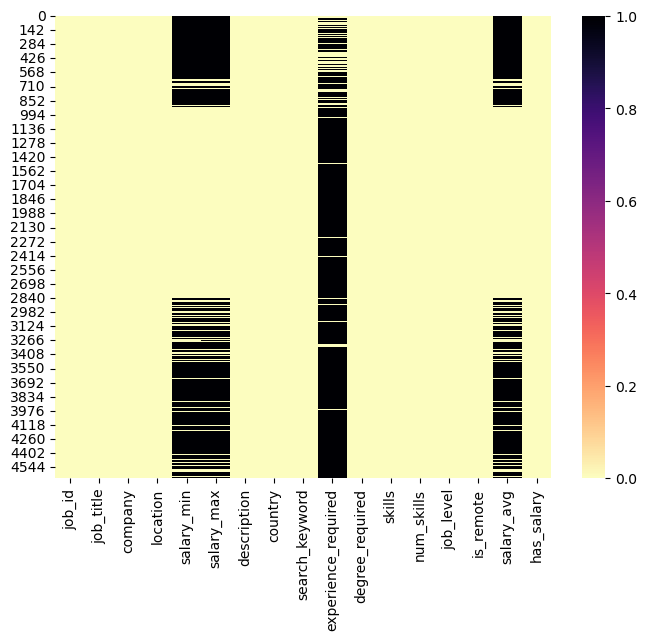

In [10]:
# Visualize the missing values as a heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(job_df.isnull(), cbar=True, cmap="magma_r")
plt.show()

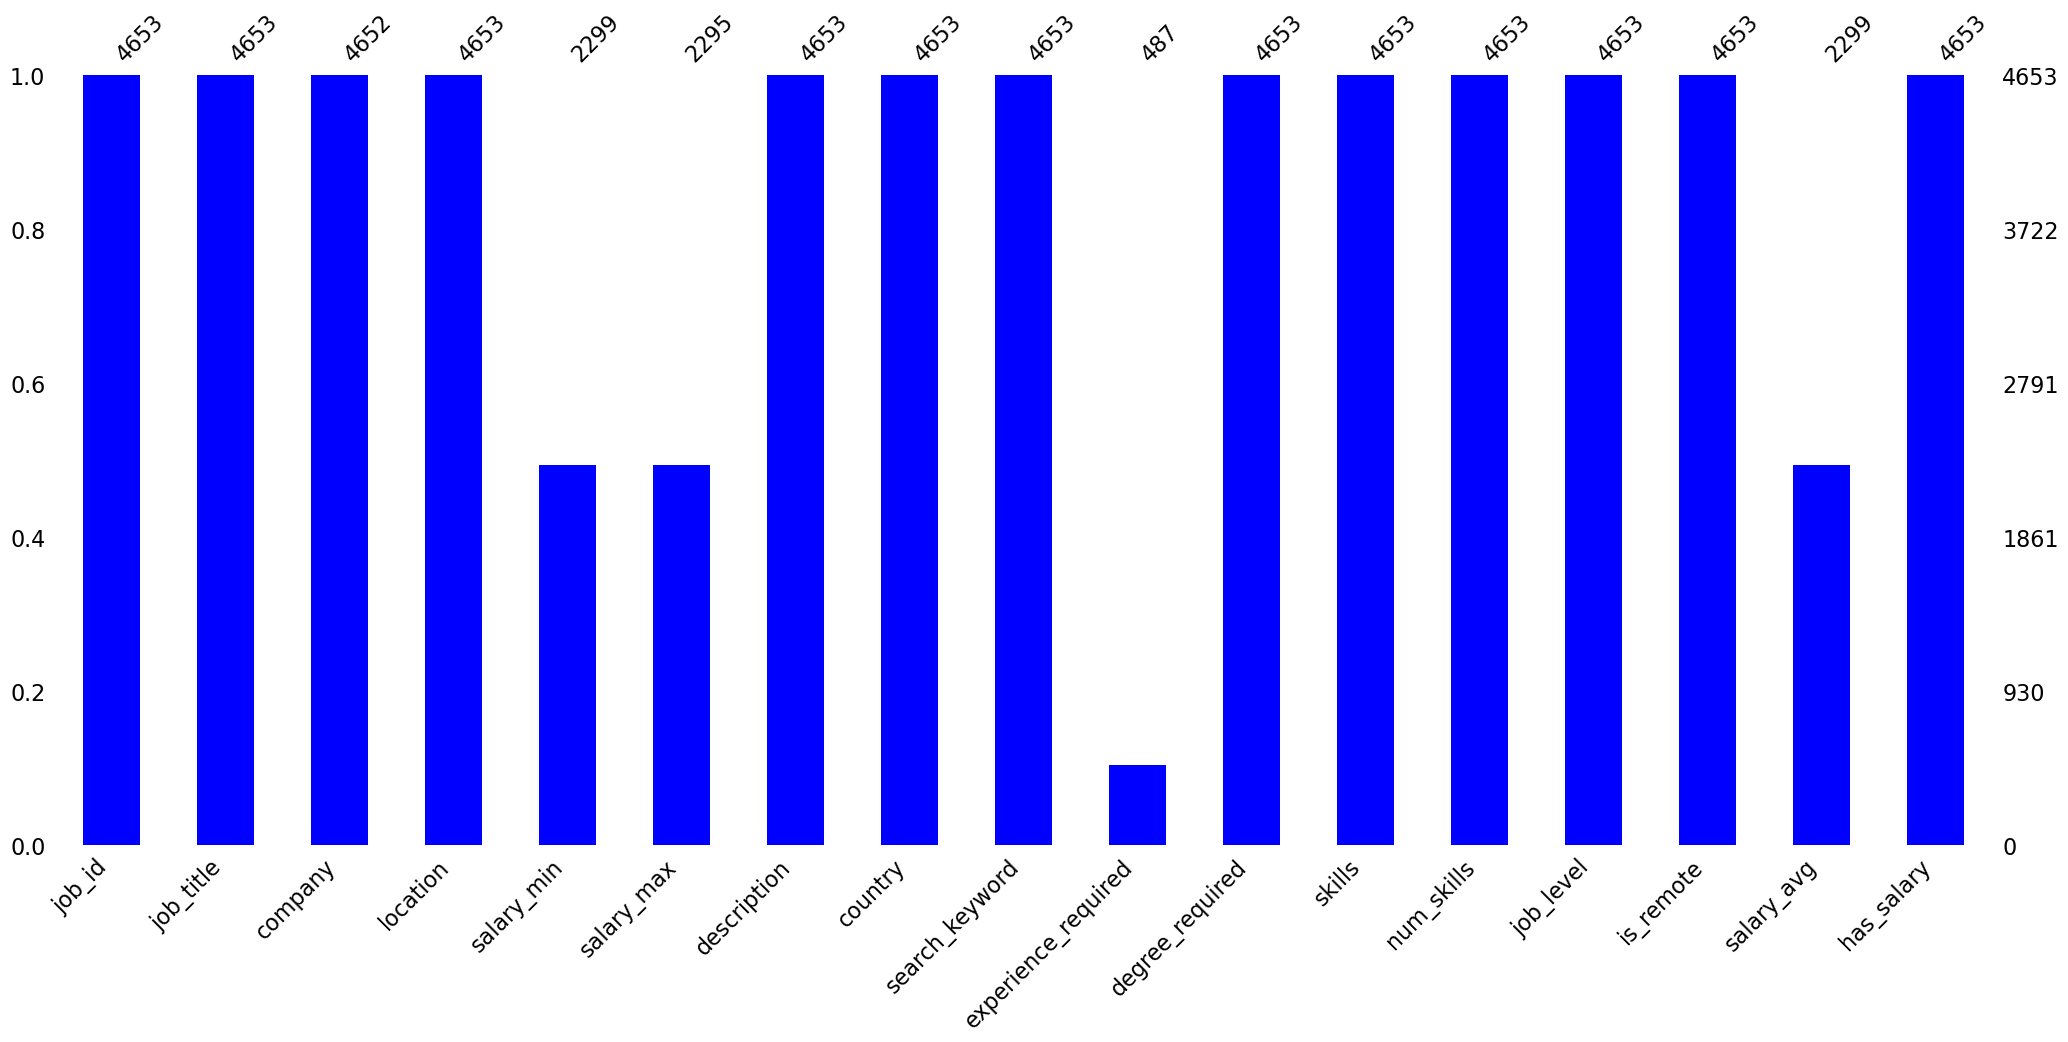

### Investigate individual Columns
#### Standardize inconsistent Categorical columns

In [69]:
# View job title
#job_df["job_title"].tolist()

In [42]:
# Check for Inconsistent Categories
# Import Regular Expression as re

import re
import numpy as np

# Convert to lowercase first
job_df["job_title"] = job_df["job_title"].str.lower().str.strip()

# Create standardized job title
job_df["job_category"] = np.select(
    [
        job_df["job_title"].str.contains(r"\bmachine\s*learning\b|\bml engineer\b|\bmle\b", regex=True),
        job_df["job_title"].str.contains(r"\bdata\s*scientist\b|\bdata\s*science\b", regex=True),
        job_df["job_title"].str.contains(r"\bdata\s*engineer\b|\bdata\s*engineering\b", regex=True),
        job_df["job_title"].str.contains(r"\bbusiness\s*analyst\b|\bbusiness\s*systems\s*analyst\b|\bbusiness\s*intelligence\s*analyst\b|\bba\b", regex=True),
        job_df["job_title"].str.contains(r"\bdata\s*analyst\b|\bdata\s*&\s*insight\s*analyst\b|\bdata\s*quality\s*analyst\b|\bdata\s*research\s*analyst\b", regex=True),
    ],
    [
        "Machine Learning Engineer",
        "Data Scientist",
        "Data Engineer",
        "Business Analyst",
        "Data Analyst"
    ],
    default="Other"
)

In [43]:
job_df["job_category"].value_counts()

job_category
Data Engineer                959
Data Scientist               874
Business Analyst             844
Data Analyst                 823
Machine Learning Engineer    791
Other                        362
Name: count, dtype: int64

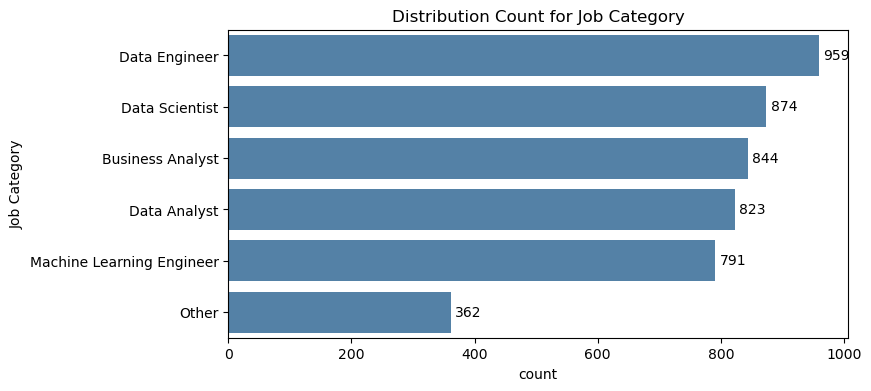

In [66]:
# Visualize Job Category

# Get categories in descending order of frequency
order = job_df["job_category"].value_counts().index

plt.figure(figsize=(8, 4))

ax = sns.countplot(job_df["job_category"],color="steelblue", order=order)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Distribution Count for Job Category")
plt.ylabel("Job Category")
plt.show()

In [74]:
# 
# Clean company title and convert case
job_df["company_clean"] = (
    job_df["company"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Get companies appearing more than 5 times
major_companies = (
    job_df["company_clean"]
    .value_counts()
    .loc[lambda x: x > 5]
    .index
)

# Build Automated regex pattern
def make_company_pattern(company):
    escaped = re.escape(company)
    escaped = escaped.replace(r"\ ", r"\s+")
    return rf"\b{escaped}\b"

company_patterns = {
    company.title(): make_company_pattern(company)
    for company in major_companies
}

# Apply mapping
for standard_name, pattern in company_patterns.items():
    mask = job_df["company_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )
    job_df.loc[mask, "company_clean"] = standard_name

# View output
job_df["company_clean"].value_counts().head(30)

company_clean
Itonlinelearning Recruitment    256
Indeed                          119
Booz Allen Hamilton             105
Insight Global                   89
Targeted Talent                  78
Cognizant                        55
Vontier                          47
Canva                            46
Cayuse Holdings                  45
It Career Switch                 44
Brink'S                          43
Ford Motor Company               42
Rxbenefits                       38
Hays                             38
Iqvia                            37
Tata Consultancy Services        36
Robert Half                      35
Kforce Technology Staffing       35
Royal Bank Of Canada             34
Neara                            27
Autodesk                         26
Judge Group                      25
Anson Mccade                     23
Itol Recruit                     22
Talenza                          20
Leidos                           19
Amazon                           18
Turing        

#### Handling Degree Required

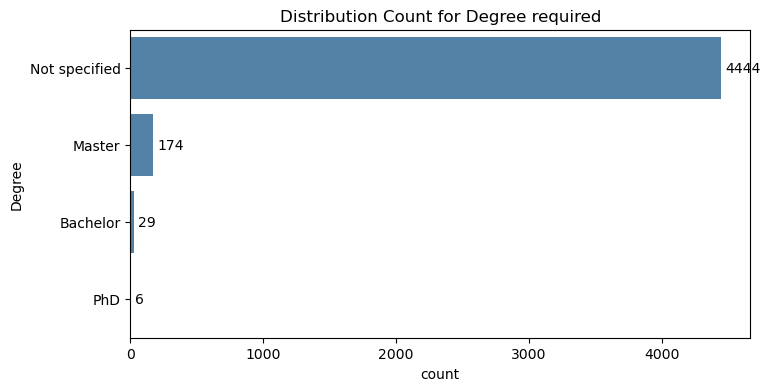

In [78]:
# Visualize Degree Required

# Get categories in descending order of frequency
order = job_df["degree_required"].value_counts().index

plt.figure(figsize=(8, 4))

ax = sns.countplot(job_df["degree_required"],color="steelblue", order=order)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Distribution Count for Degree required")
plt.ylabel("Degree")
plt.show()

In [12]:
# Count all missing values
missing_count = job_df.isnull().sum()

# Calculate the percentage of missing values
missing_perct = (missing_count / len(job_df) * 100).round(2)

# Convert into DataFrame by creating a Dictionary of missing_count and missing_perct
missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_perct
}).sort_values("Missing %", ascending=False)

# Displaying values > 0.0
missing_df[missing_df["Missing %"] > 0.0]

,Missing Count,Missing %
experience_required,4166,89.53
salary_max,2358,50.68
salary_avg,2354,50.59
salary_min,2354,50.59
company,1,0.02


In [68]:
# View job title
#job_df["company"].tolist()

***Comment:***
- The DataFrame shows that a substantial amount of data is missing in the listed features
- We will drop features with missing values over 80%.
- We will check for outliers before deciding which statistical model to adopt in filling the missing values

### Visualize Distribution Tables

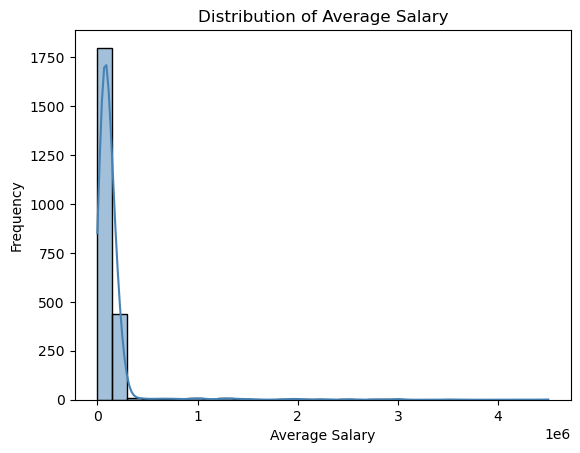

In [25]:
# Distribution of Average Salary
sns.histplot(
    data=job_df,
    x="salary_avg",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Investigate salary columns with categorical data

job_df["has_salary"].nunique()
job_df["has_salary"].value_counts().head()

In [13]:
# Drop column with 80-100% missing values

job_df.drop(columns = ["experience_required"], inplace=True)

In [14]:
# There are inconsistencies between the value counts of salary_avg and has_salary, which cause a mismatch
# Locate the rows and drop them

row_problem = job_df[
    (
        (job_df["has_salary"]==False) &
        (job_df["salary_avg"].notna()))
]

salary_problem


,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary
3129,5703188331,"data analyst – etl, sql",Astra North Infoteck Inc.,"Toronto, Ontario",10000.0,NaN,Job Description: Role: BSA/ Tech Lead Duration...,Canada,data analyst,Not specified,[],0,Mid,False,10000.0,False
3200,5707869833,data engineer,SereneAid,"Montréal East, Montréal",10000.0,NaN,"Position: Data Engineer Location: Montreal, QC...",Canada,data engineer,Not specified,[],0,Mid,False,10000.0,False
3267,5709195766,azure data engineer,Astra North Infoteck Inc.,"Toronto, Ontario",10000.0,NaN,Job Description: Job Title: Azure Data Enginee...,Canada,data engineer,Not specified,[],0,Mid,False,10000.0,False
3386,5699755645,machine learning engineer,Astra North Infoteck Inc.,"Toronto, Ontario",10000.0,NaN,Primary Skill /s - Machine Learning to Custome...,Canada,machine learning engineer,Not specified,"['python', 'machine learning', 'aws', 'spark']",4,Mid,False,10000.0,False


#### Checking for outliers using a box plot

columns = ["salary_min", "salary_max", "salary_avg"]

for col in columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(data=job_df, x=col)

    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


***Comment:***
Since there are outliers found within the missing values, the median would be adopted as best fit for missing values

#### Defining missing values
median_min = job_df["salary_min"].median()

median_max = job_df["salary_max"].median()

median_avg = job_df["salary_avg"].median()

mode_comp = job_df["company"].mode()[0]   # Since only 1 missing value was found, we can justifiably use mode without fear of bias

mode_comp

#### Filling missing values with median

job_df["salary_min"] = job_df["salary_min"].fillna(median_min, inplace=False)

job_df["salary_max"] = job_df["salary_max"].fillna(median_max, inplace=False)

job_df["salary_avg"] = job_df["salary_avg"].fillna(median_avg, inplace=False)

job_df["company"] = job_df["company"].fillna(mode_comp, inplace=False)

In [104]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           4653 non-null   int64  
 1   job_title        4653 non-null   object 
 2   company          4653 non-null   object 
 3   location         4653 non-null   object 
 4   salary_min       4653 non-null   float64
 5   salary_max       4653 non-null   float64
 6   description      4653 non-null   object 
 7   country          4653 non-null   object 
 8   search_keyword   4653 non-null   object 
 9   degree_required  4653 non-null   object 
 10  skills           4653 non-null   object 
 11  num_skills       4653 non-null   int64  
 12  job_level        4653 non-null   object 
 13  is_remote        4653 non-null   bool   
 14  salary_avg       4653 non-null   float64
 15  has_salary       4653 non-null   bool   
 16  job_category     4653 non-null   object 
dtypes: bool(2), fl

In [66]:
job_df.describe()

,job_id,salary_min,salary_max,num_skills,salary_avg
count,4.653000e+03,4.653000e+03,4.653000e+03,4653.000000,4.653000e+03
mean,5.639829e+09,8.288952e+04,9.118422e+04,0.383838,8.822215e+04
std,3.094779e+08,2.546859e-09,9.823598e-09,0.680850,5.486662e-09
min,1.155088e+09,8.288952e+04,9.118422e+04,0.000000,8.822215e+04
25%,5.679737e+09,8.288952e+04,9.118422e+04,0.000000,8.822215e+04
50%,5.696178e+09,8.288952e+04,9.118422e+04,0.000000,8.822215e+04
75%,5.704005e+09,8.288952e+04,9.118422e+04,1.000000,8.822215e+04
max,5.711046e+09,8.288952e+04,9.118422e+04,5.000000,8.822215e+04


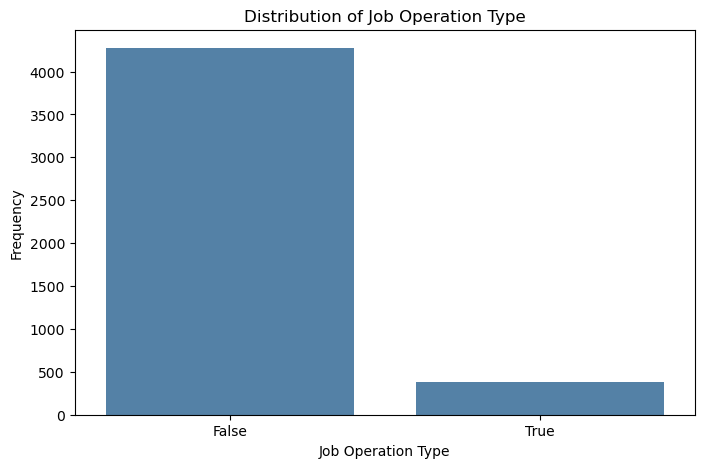

In [90]:
# Distribution of Job Operation Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x="is_remote",
    color="steelblue",
    order=job_df["is_remote"].value_counts().index
)

plt.title("Distribution of Job Operation Type")
plt.xlabel("Job Operation Type")
plt.ylabel("Frequency")

plt.show()

##### Check for Uniqueness of ALL Object Data types

In [94]:
# job_df["job_title"].tolist()


job_category
Data Engineer                959
Data Scientist               874
Business Analyst             844
Data Analyst                 823
Machine Learning Engineer    791
Other                        362
Name: count, dtype: int64

In [73]:
job_df["job_level"].nunique()
job_df["job_level"].value_counts().head()

job_level
Mid       3442
Senior     846
Lead       293
Junior      72
Name: count, dtype: int64

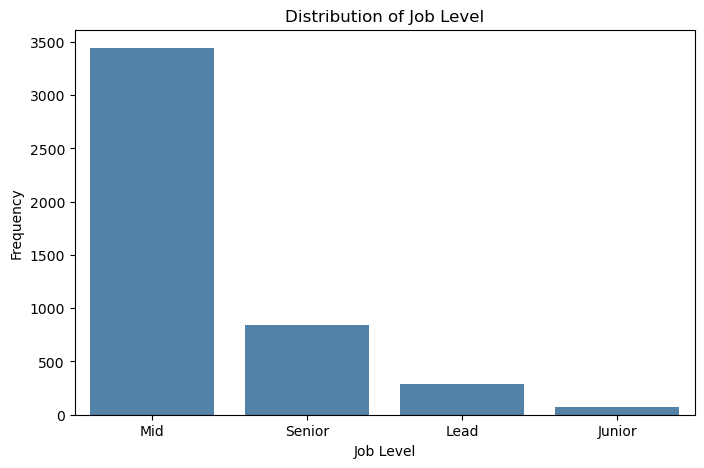

In [91]:
# Distribution of Job level
plt.figure(figsize=(8,5))

sns.countplot(
    data=job_df,
    x="job_level",
    color="steelblue",
    order=job_df["job_level"].value_counts().index
)

plt.title("Distribution of Job Level")
plt.xlabel("Job Level")
plt.ylabel("Frequency")

plt.show()

In [102]:
job_df["has_salary"].value_counts()

has_salary
False    2358
True     2295
Name: count, dtype: int64